# Fase 3 — Preprocesamiento y reducción de dimensionalidad
**Grupo 3 · Evento Evaluativo 2 · Análisis de Datos**
Continuamos sobre el dataset **Titanic**, aplicando lo encontrado en la Fase 2 (`02_eda.ipynb`).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (8, 4)
sns.set_style('whitegrid')

titanic = sns.load_dataset('titanic')
titanic.shape

(891, 15)

## 3.1 Limpieza según lo decidido en la Fase 2

In [2]:
df = titanic.copy()

# deck: ~77% de faltantes -> se elimina (ver Fase 2, sección 2.1)
df = df.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male', 'alone'])

# age: se imputa con la mediana (más robusta a outliers que la media)
df['age'] = df['age'].fillna(df['age'].median())

# embarked: se imputa con la moda (solo 2 valores faltantes)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print('Valores faltantes restantes:')
print(df.isnull().sum())
df.head()

Valores faltantes restantes:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 3.2 Codificación de variables categóricas

In [3]:
# Label encoding para 'sex' (binaria: male/female)
le = LabelEncoder()
df['sex_encoded'] = le.fit_transform(df['sex'])
print('Mapeo sex:', dict(zip(le.classes_, le.transform(le.classes_))))

# One-hot encoding para 'embarked' (3 categorías sin orden natural); 'pclass' ya es ordinal numérica y se deja tal cual
df_encoded = pd.get_dummies(df, columns=['embarked'], prefix='embarked')
df_encoded.head()

Mapeo sex: {'female': np.int64(0), 'male': np.int64(1)}


,survived,pclass,sex,age,sibsp,parch,fare,sex_encoded,embarked_C,embarked_Q,embarked_S
0,0,3,male,22.0,1,0,7.2500,1,False,False,True
1,1,1,female,38.0,1,0,71.2833,0,True,False,False
2,1,3,female,26.0,0,0,7.9250,0,False,False,True
3,1,1,female,35.0,1,0,53.1000,0,False,False,True
4,0,3,male,35.0,0,0,8.0500,1,False,False,True


**Justificación:** se usó *label encoding* para `sex` porque es binaria (no genera una jerarquía falsa con solo 2 valores). Se usó *one-hot encoding* para `embarked` porque sus 3 categorías (C, Q, S) no tienen un orden natural — usar label encoding ahí introduciría una relación numérica inexistente entre los puertos.

## 3.3 Escalado de variables numéricas

In [4]:
numeric_features = ['age', 'fare', 'sibsp', 'parch']

minmax = MinMaxScaler()
df_norm = df_encoded.copy()
df_norm[numeric_features] = minmax.fit_transform(df_encoded[numeric_features])

standard = StandardScaler()
df_std = df_encoded.copy()
df_std[numeric_features] = standard.fit_transform(df_encoded[numeric_features])

comparacion = pd.DataFrame({
    'original_fare': df_encoded['fare'].head(),
    'fare_normalizado_0_1': df_norm['fare'].head(),
    'fare_estandarizado': df_std['fare'].head(),
})
comparacion

,original_fare,fare_normalizado_0_1,fare_estandarizado
0,7.2500,0.014151,-0.502445
1,71.2833,0.139136,0.786845
2,7.9250,0.015469,-0.488854
3,53.1000,0.103644,0.420730
4,8.0500,0.015713,-0.486337


**Normalización (MinMaxScaler)** lleva todo a un rango [0,1] — útil para algoritmos basados en distancias (k-NN) o redes neuronales. **Estandarización (StandardScaler)** centra en media 0 y desviación estándar 1 — más adecuada cuando los datos se acercan a una distribución normal y para PCA, que es sensible a la escala (ver Semana 5 de la guía del curso). Nota: en este notebook solo se escalan las variables numéricas continuas (`age`, `fare`, `sibsp`, `parch`); `pclass`, `sex_encoded` y los dummies de `embarked` se dejan en su escala original.

## 3.4 Reducción de dimensionalidad con PCA

In [5]:
features_pca = ['pclass', 'sex_encoded', 'age', 'sibsp', 'parch', 'fare',
                'embarked_C', 'embarked_Q', 'embarked_S']
X = StandardScaler().fit_transform(df_encoded[features_pca].astype(float))

pca = PCA(n_components=2)
componentes = pca.fit_transform(X)

df_pca = pd.DataFrame(componentes, columns=['PC1', 'PC2'])
df_pca['survived'] = df['survived'].values

print('Varianza explicada por componente:', pca.explained_variance_ratio_.round(3))
print('Varianza total explicada por las 2 primeras componentes:', round(pca.explained_variance_ratio_.sum()*100, 1), '%')

Varianza explicada por componente: [0.239 0.196]
Varianza total explicada por las 2 primeras componentes: 43.6 %


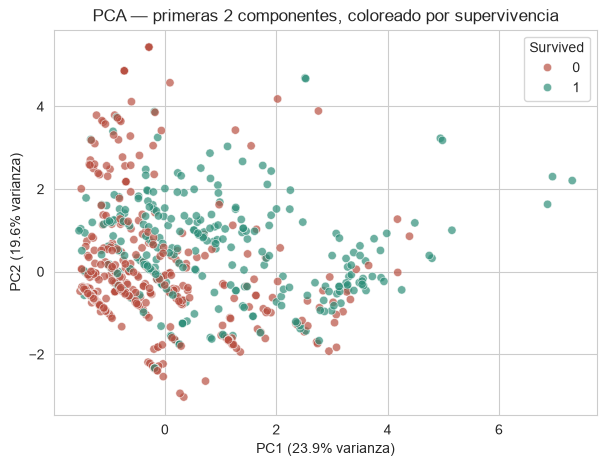

In [6]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='survived', palette=['#B85042', '#2F8F7A'], alpha=0.7)
plt.title('PCA — primeras 2 componentes, coloreado por supervivencia')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
plt.legend(title='Survived')
plt.show()

In [7]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features_pca)
loadings.sort_values('PC1', key=abs, ascending=False)

,PC1,PC2
embarked_C,0.544200,-0.146221
embarked_S,-0.488164,0.314976
fare,0.454135,0.307749
pclass,-0.429622,-0.113009
sex_encoded,-0.211689,-0.274435
age,0.159858,-0.214896
parch,0.061766,0.552671
embarked_Q,0.018151,-0.296964
sibsp,-0.014732,0.506756


**Interpretación:**
- Las dos primeras componentes explican el 43.6% de la varianza total (23.9% + 19.6%). Es una fracción modesta: al pasar de 9 dimensiones a 2 con variables mixtas (numéricas + dummies) se pierde más de la mitad de la información.
- **Loadings:** como ahora las 9 variables están estandarizadas, todas compiten en igualdad de escala. PC1 la dominan `embarked_C` (0.54), `embarked_S` (−0.49), `fare` (0.45) y `pclass` (−0.43): contrasta a quienes embarcaron en Cherburgo y pagaron tarifas altas / viajaron en primera clase contra quienes embarcaron en Southampton, con tarifas bajas y clases inferiores. PC2 la dominan `parch` (0.55) y `sibsp` (0.51), es decir, el tamaño del grupo familiar; también aportan `embarked_Q` (−0.30), `fare` (0.31) y `sex_encoded` (−0.27).
- **Scatter plot:** hay una separación **parcial** entre sobrevivientes y no sobrevivientes a lo largo de PC1: los no sobrevivientes se concentran a la izquierda (valores bajos de PC1) y los sobrevivientes se extienden hacia la derecha (tarifas altas, primera clase, puerto C). Aun así los grupos se superponen bastante en la zona central, por lo que dos componentes no bastan para resumir la supervivencia.

**Limitaciones:** PCA asume relaciones **lineales** entre las variables y es sensible a la escala (por eso se estandarizaron las 9 variables antes de aplicarlo). Además, con variables 0/1 la interpretación geométrica de PCA es menos natural que con variables continuas.